In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

from datetime import date

import sys
import cmdstanpy

print(f"Python Executable: {sys.executable}")
print(f"CmdStanPy Version:   {cmdstanpy.__version__}")
print(f"CmdStanPy Path:      {cmdstanpy.__file__}")

Python 3.10.13
Python Executable: /opt/conda/envs/texas-env/bin/python
CmdStanPy Version:   1.2.5
CmdStanPy Path:      /opt/conda/envs/texas-env/lib/python3.10/site-packages/cmdstanpy/__init__.py


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat
import xesmf as xe

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path
from typing import Union, Optional, Dict, List, Tuple, Sequence

import importlib

from TEXAS.stan.sampler import get_posterior, load_posterior
from TEXAS.ensemble.generator import generate_ensemble, generate_ensemble_auto
from TEXAS.plotting import prior_plot as ppd
from TEXAS.stan.invT import build_invT_inputData
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.io import load_posterior
from TEXAS.data.builder import build_invT_inputData, InvTConfig

import TEXAS
print("TEXAS version",TEXAS.__version__)  


import bayspline as bsl
import bayspar as bsr



TEXAS version 0.1.0


# Miscellaneous functions

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

# Concordance correlation coefficient (CCC)
def concordance_corr_coef(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

def running_mean(x, y, window_size):
    df = pd.DataFrame({'x': x, 'y': y})
    df = df.sort_values(by='x')
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    return df['x'], df['y_running_mean']


def running_mean_log10(x, y, window_size, weights=None):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    if weights is not None:
        df['y_running_mean'] = df['y_running_mean'] * weights
    
    return df['log_x'], df['y_running_mean']

def running_median_log10(x, y, window_size):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_median'] = df['y'].rolling(window=window_size, center=True).median()
    
    return df['log_x'], df['y_running_median']
    
    
def flag_quantile_outliers(df, x_col, y_col, 
                           nbins=30, lower_q=0.10, upper_q=0.90):
    df = df.copy()
    df['bin'] = pd.qcut(np.log10(df[x_col]), q=nbins, duplicates='drop')
    df['outlier'] = False

    for b in df['bin'].unique():
        bin_mask = df['bin'] == b
        residuals_in_bin = df.loc[bin_mask, y_col]
        q_low = np.nanquantile(residuals_in_bin, lower_q)
        q_high = np.nanquantile(residuals_in_bin, upper_q)

        outlier_mask = (residuals_in_bin < q_low) | (residuals_in_bin > q_high)
        df.loc[bin_mask, 'outlier'] = outlier_mask

    return df


def bland_altman_metrics_calculation(data1, data2):
    """"

    # Example to use the metrics
    # fig, axs = plot.subplots()
    # axs.scatter(mean, diff, *args, **kwargs)  # Plot differences against means
    # axs.axhline(md, color='gray', linestyle='--', label='Mean Difference')
    # axs.axhline(md + 1.96 * sd, color='orange', linestyle='--', label='+1.96 SD (Upper LoA)')
    # axs.axhline(md - 1.96 * sd, color='magenta', linestyle='--', label='-1.96 SD (Lower LoA)')
    """
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    
    mean = np.mean([data1, data2], axis=0)  # Calculate the average of the two measurements
    diff = data1 - data2  # Calculate the difference between the two measurements
    
    md = np.mean(diff)  # Mean of the differences (estimated bias)
    sd = np.std(diff, axis=0)  # Standard deviation of the differences
    

    
    return mean, diff, md, sd



# Previous TEX86 calibration models

In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/TEXAS /home/micromamba/app/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [8]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [9]:
def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Raw coretop

In [10]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['pred_new_texRI'] = pred_texRI(raw_coretop_df['TEX86'], method_name='exp_thisStudy')
raw_coretop_df['new_deltaRI'] = raw_coretop_df['scaledRI'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,deltaRI_group,pred_new_texRI,new_deltaRI
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0,6.0,31.651700,34.07330,562.0,0.662000,...,0.003865,0.025728,NaN,NaN,NaN,NaN,NaN,NaN,2.649848,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,8.300386,5.318187,10.0,East Equatorial Pacific,1.886982,0.894152,False,-0.3 to 0.3,2.434261,-1.848859
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0,1.0,-3.710500,-81.11530,378.0,0.570000,...,5.804398,4.208444,NaN,NaN,NaN,NaN,NaN,NaN,2.322082,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0,1.0,-3.750200,-81.13580,379.0,0.572000,...,7.112034,5.378340,NaN,NaN,NaN,NaN,NaN,NaN,2.328756,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,6.462469,4.969550,10.0,East Equatorial Pacific,1.217141,0.946764,False,-0.3 to 0.3,2.422321,-1.780690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,3.155563,3.107517,60.0,Baffin Bay,4.267857,0.707148,False,>0.3,1.819351,-1.520851
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,3.043328,2.995078,60.0,Baffin Bay,3.700127,0.751740,False,>0.3,1.628025,-1.355025
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,2.829360,2.795761,60.0,Baffin Bay,4.128651,0.718082,False,>0.3,1.755230,-1.450230
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,0.917937,0.575588,61.0,Tasman Sea,1.925943,0.891092,False,-0.3 to 0.3,2.684958,-2.062401


# Gridded coretop

In [11]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [12]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)

display(coretop_df)

coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  # remove outliers
coretop_df_below70N = coretop_df[coretop_df['lat']<70].reset_index(drop=True)

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,3960.0,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832


# Generalized logistic function

In [13]:
def generalized_logistic_model(x, x0, A, K, B, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - x: Independent variable (e.g., temperature)
    - x0: Inflection point (the value of x at which the function changes from concave down to concave up)
    
    - A: Lower asymptote (left asymptote)
    - K: the right horizontal asymptote when C = 1. If A = 0 and C = 1, then K is the carrying capacity.
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + (K - A) / np.power(C + Q * np.exp(-B * (x - x0)), 1/v)

    return Y

In [14]:
def generalized_logistic_inflection_point(x0, B, v):
    """
    Calculate the inflection point of a generalized logistic function.

    Parameters:
    - x0 (float or array): center/shift parameter
    - B (float or array): growth rate
    - v (float or array): shape/asymmetry parameter (nu)

    Returns:
    - Inflection point (same shape as input)
    """
    return x0 + np.log(v) / B

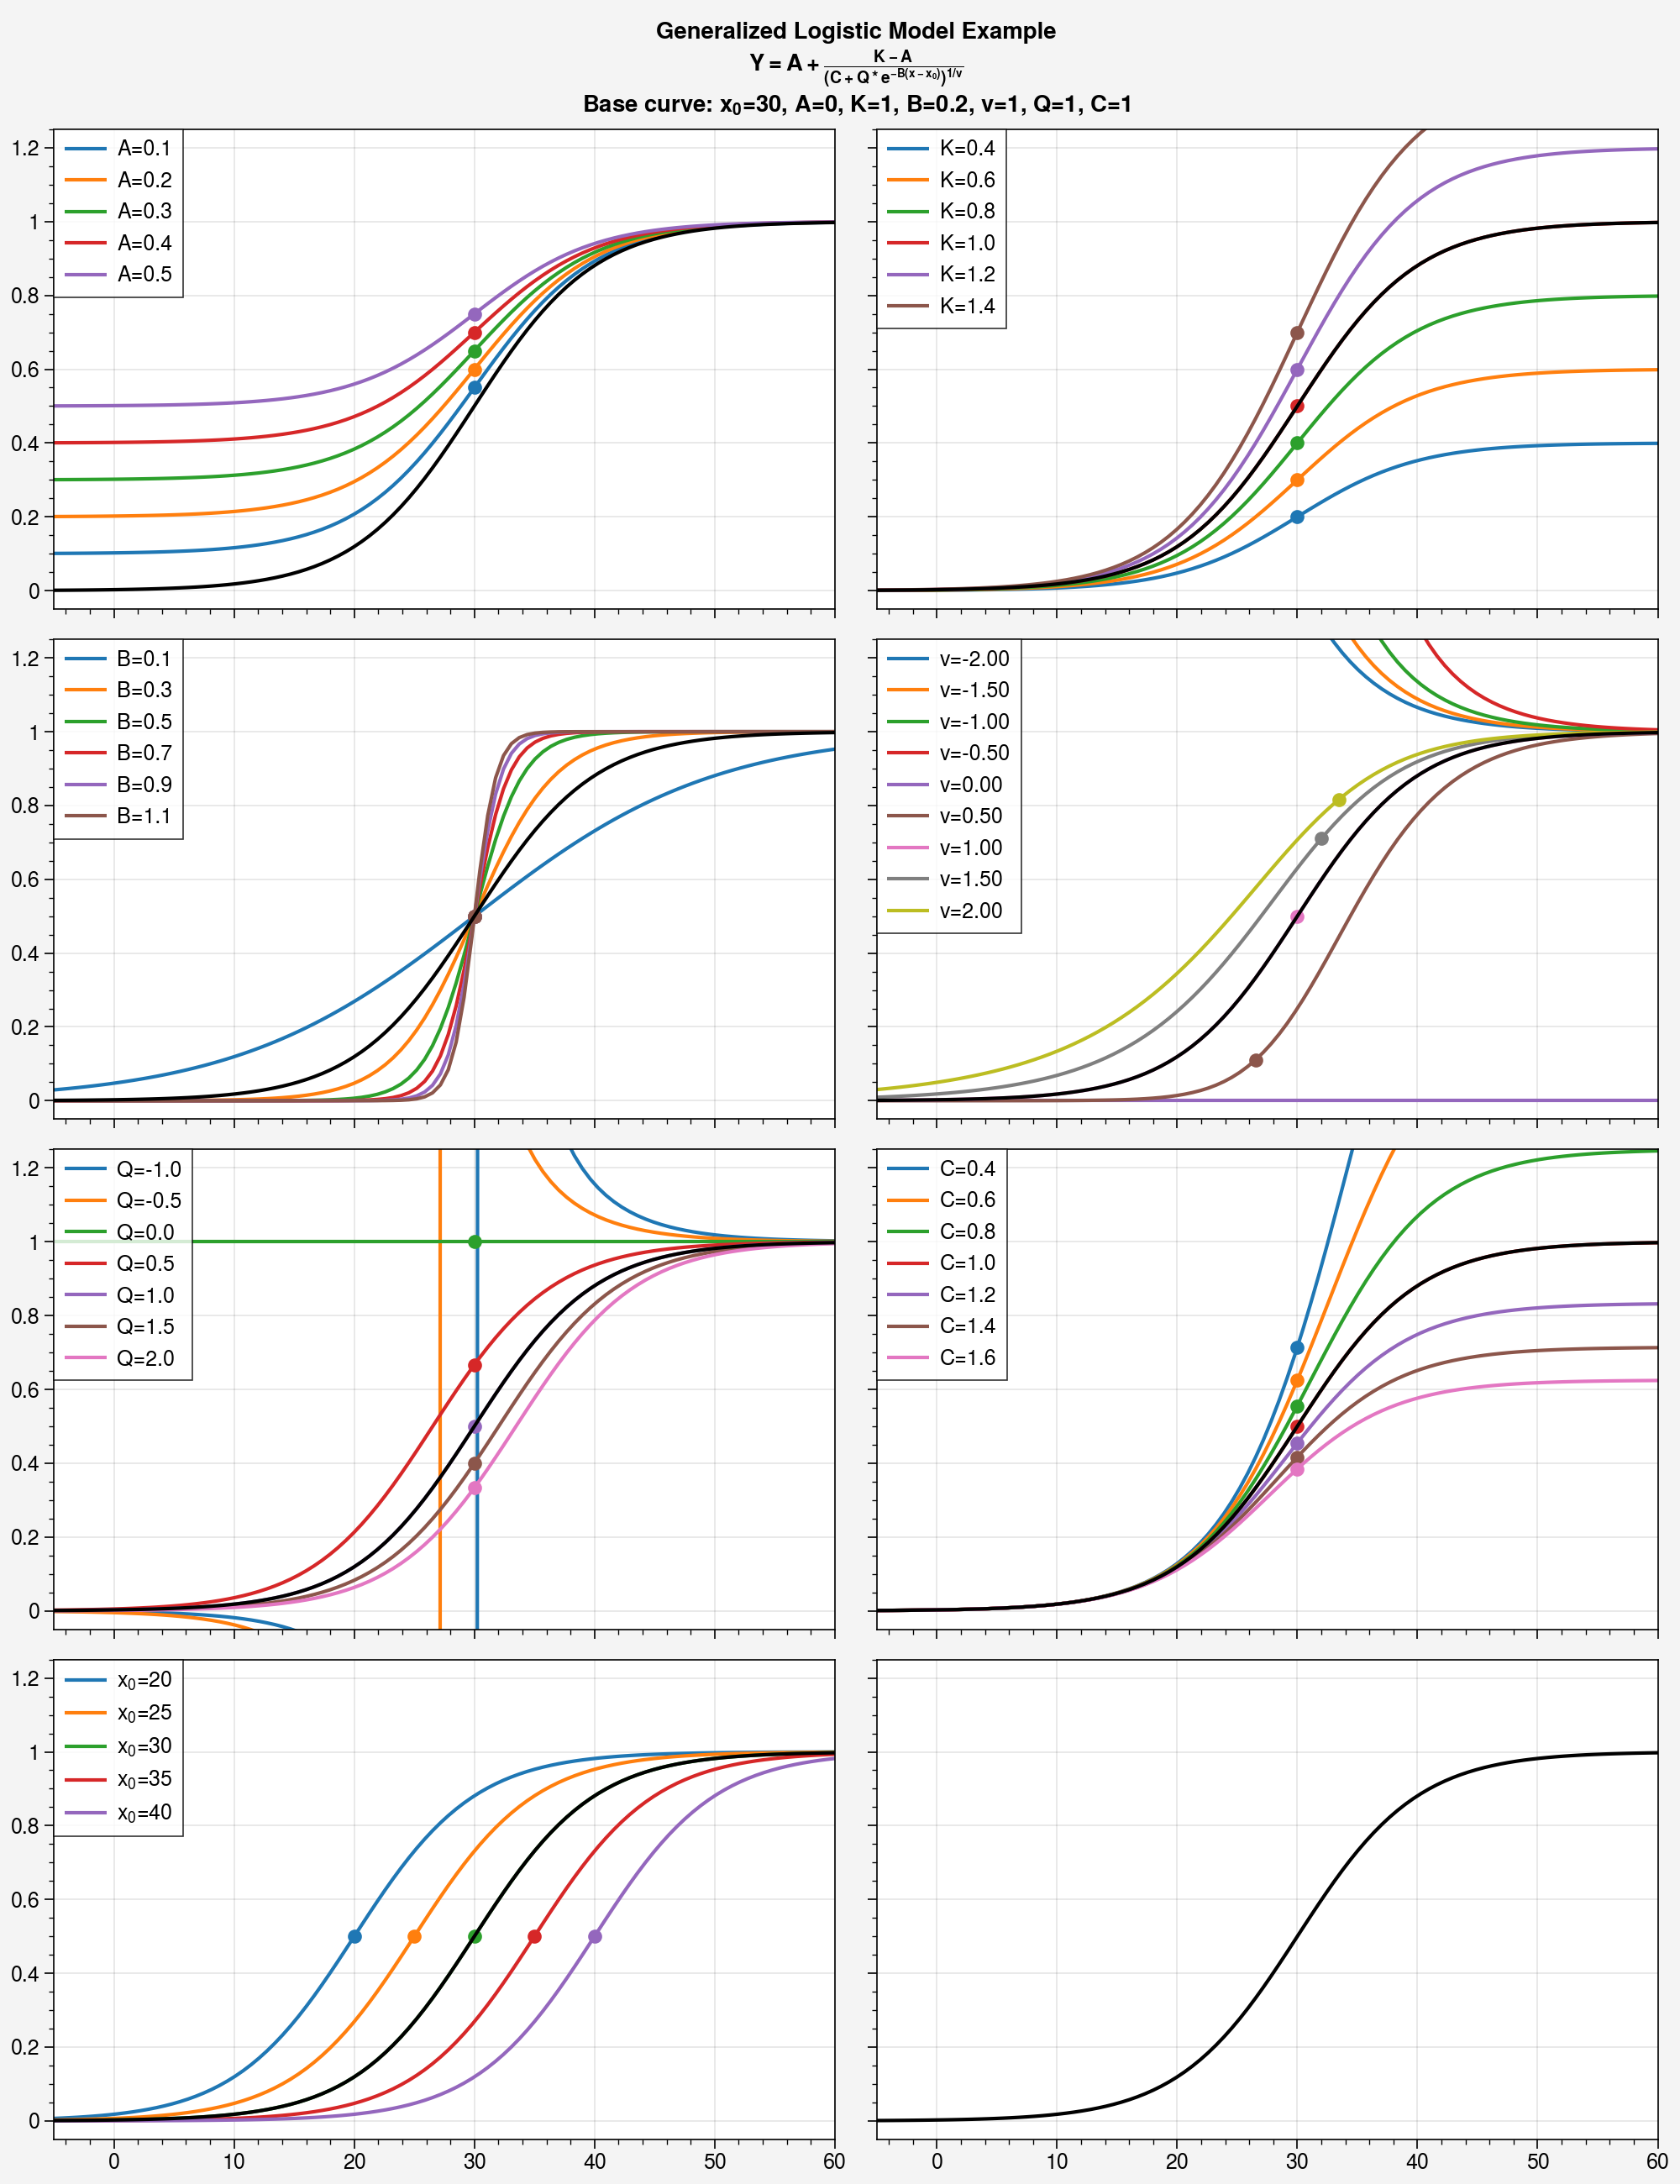

In [15]:
xx = np.linspace(-5,60,100)
sel_a = 0
sel_k = 1
sel_b = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30


fig, axs = plot.subplots(figsize=(10,13),nrows=4,ncols=2)

### varying A
AA = np.arange(0.1, 0.51, 0.1)
for i, a in enumerate(AA):
    sel_c = plot.get_colors('tab10', len(AA))
    pred_y = generalized_logistic_model(
        A=a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[0].plot(xx, pred_y, label=f'A={a:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[0].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

axs.format(
    ylim=(-0.05, 1.05),
)

### varying K
KK = np.arange(0.4, 1.41, 0.2)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = generalized_logistic_model(
        A=sel_a,K=k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[1].plot(xx, pred_y, label=f'K={k:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[1].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying B
BB = np.arange(0.1, 1.2, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[2].plot(xx, pred_y, label=f'B={b:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[2].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')

h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying v
VV = np.arange(-2, 2.01, 0.5)
for i, v in enumerate(VV):
    sel_c = plot.get_colors('tab10', len(VV))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[3].plot(xx, pred_y, label=f'v={v:.2f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[3].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying Q
QQ = np.arange(-1.0, 2.4, 0.5)
for i, q in enumerate(QQ):
    sel_c = plot.get_colors('tab10', len(QQ))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=q,C=1,
        x=xx,x0=sel_x0
    )
    axs[4].plot(xx, pred_y, label=f'Q={q:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[4].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[4].get_legend_handles_labels()
axs[4].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


#### varying C
CC = np.arange(0.4, 1.61, 0.2)
for i, c in enumerate(CC): 
    sel_c = plot.get_colors('tab10', len(CC))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=c,
        x=xx,x0=sel_x0
    )
    axs[5].plot(xx, pred_y, label=f'C={c:.1f}', color=sel_c[i])
    

    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=c,
        x=inflection_x,x0=sel_x0
    )
    axs[5].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[5].get_legend_handles_labels()
axs[5].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


### Varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=x0
    )
    axs[6].plot(xx, pred_y, label=r'x$_{0}$='+f'{x0}', color=sel_c[i])

    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=x0
    )
    axs[6].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[6].get_legend_handles_labels()
axs[6].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


##############################################################

sel_a = 0
sel_k = 1
sel_b = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30
pred_y = generalized_logistic_model(
    A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
    x=xx,x0=sel_x0
)

axs.plot(xx, pred_y, label='Generalized Logistic Model', color='k')
eq_str = r'$Y = A + \frac{K - A}{(C + Q * e^{-B(x - x_{0})})^{1/v}}$'
text_str = fr'Base curve: x$_{0}$='+f'{sel_x0}, A={sel_a}, K={sel_k}, B={sel_b}, v={sel_v}, Q={sel_q}, C=1'

axs.format(
    suptitle=f'Generalized Logistic Model Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

| Parameter | Description                                 | Increasing →                                                           | Decreasing →                                                    | Notes                                              |
| --------- | ------------------------------------------- | ---------------------------------------------------------------------- | --------------------------------------------------------------- | -------------------------------------------------- |
| **A**     | Lower asymptote (left horizontal level)     | Curve starts from a **higher baseline**                                | Curve starts from a **lower baseline**                          | See top-left subplot (A=0.1–0.5)                   |
| **K**     | Upper asymptote (right horizontal level)    | Curve levels off **higher**                                            | Curve levels off **lower**                                      | See top-right subplot                              |
| **B**     | Growth rate / steepness                     | Curve becomes **steeper**, transitions more abruptly                   | Curve becomes **flatter**, transitions more gradually           | See middle-left subplot                            |
| **ν (v)** | Asymmetry / shape                           | Inflection point shifts **right**, curve becomes more **right-skewed** | Inflection point shifts **left**, curve becomes **left-skewed** | See middle-right subplot                           |
| **Q**     | Horizontal stretch / curve-start factor     | Curve shifts **rightward** and flattens                                | Curve shifts **leftward** and steepens                          | Affects timing of rise. See lower-left subplot     |
| **C**     | Additive constant inside denominator        | Delays rise and **lowers the upper asymptote** when $C > 1$            | Accelerates rise, **can overshoot** when $C < 1$                | Uncommon to vary this; see lower-middle subplot    |
| **x₀**    | Horizontal shift (center/starting location) | Shifts curve **rightward**                                             | Shifts curve **leftward**                                       | Does **not change shape**; see lower-right subplot |


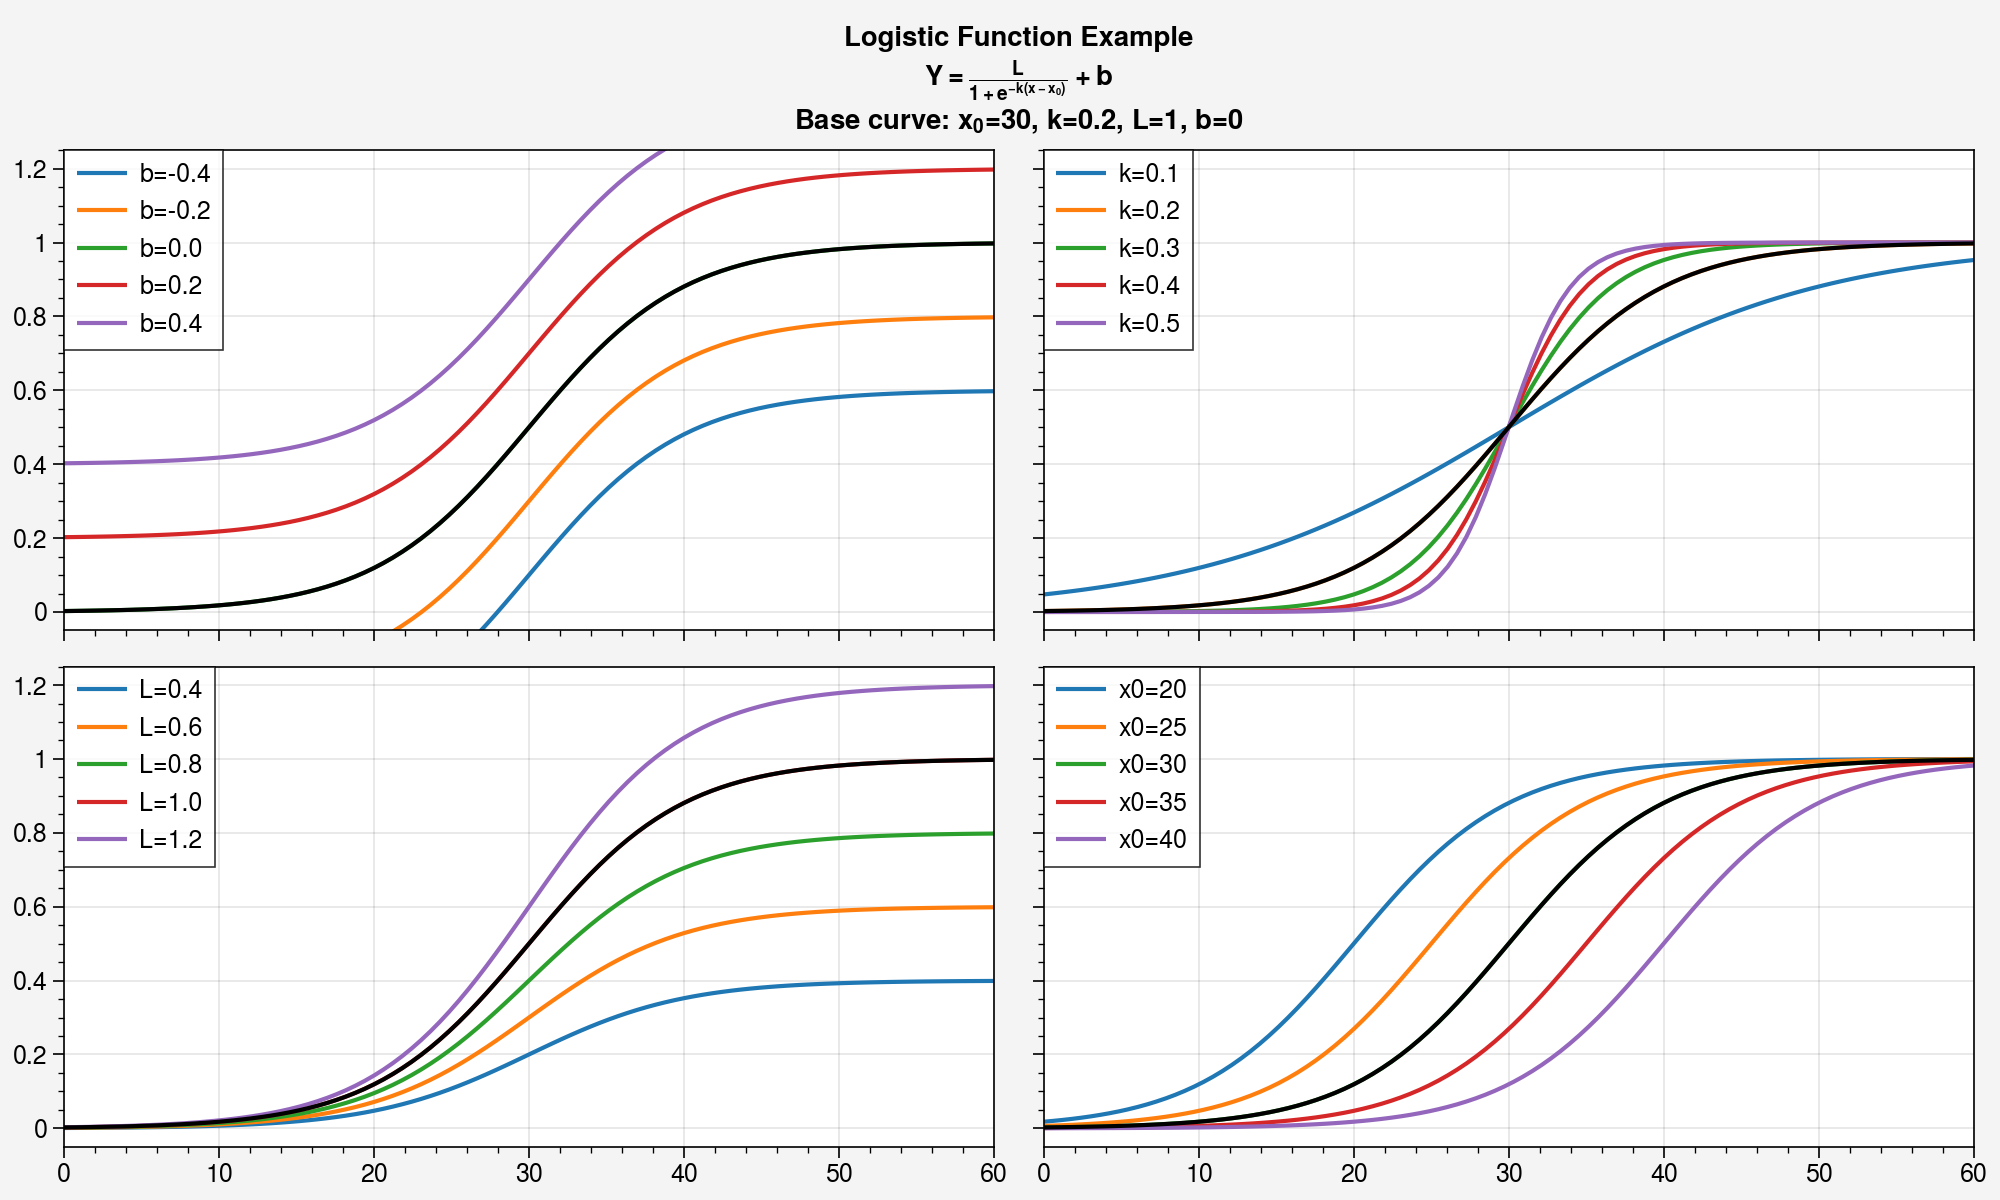

In [16]:
fig, axs = plot.subplots(figsize=(10, 6), nrows=2, ncols=2)

xx = np.linspace(0,60,100)
sel_x0 = 30
sel_b = 0
sel_L = 1
sel_k = 0.2

### varying b
BB = np.arange(-0.4, 0.41, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=sel_L, b=b)
    axs[0].plot(xx, pred_y, label=f'b={b:.1f}', color=sel_c[i])
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying k
KK = np.arange(0.1, 0.51, 0.1)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = logistic(xx, x0=sel_x0, k=k, L=sel_L, b=sel_b)
    axs[1].plot(xx, pred_y, label=f'k={k:.1f}', color=sel_c[i])
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying L
LL = np.arange(0.4, 1.21, 0.2)
for i, L in enumerate(LL):
    sel_c = plot.get_colors('tab10', len(LL))
    pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=L, b=sel_b)
    axs[2].plot(xx, pred_y, label=f'L={L:.1f}', color=sel_c[i])
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = logistic(xx, x0=x0, k=sel_k, L=sel_L, b=sel_b)
    axs[3].plot(xx, pred_y, label=f'x0={x0}', color=sel_c[i])
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

sel_x0 = 30
sel_k = 0.2
sel_L = 1
sel_b = 0
pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=sel_L, b=sel_b)

axs.plot(xx, pred_y, label='Logistic Function', color='k')
eq_str = r'$Y = \frac{L}{1 + e^{-k(x -x_0)}} + b$'
text_str = r'Base curve: x$_{0}$='+f'{sel_x0}, k={sel_k}, L={sel_L}, b={sel_b}'
axs.format(
    suptitle=f'Logistic Function Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

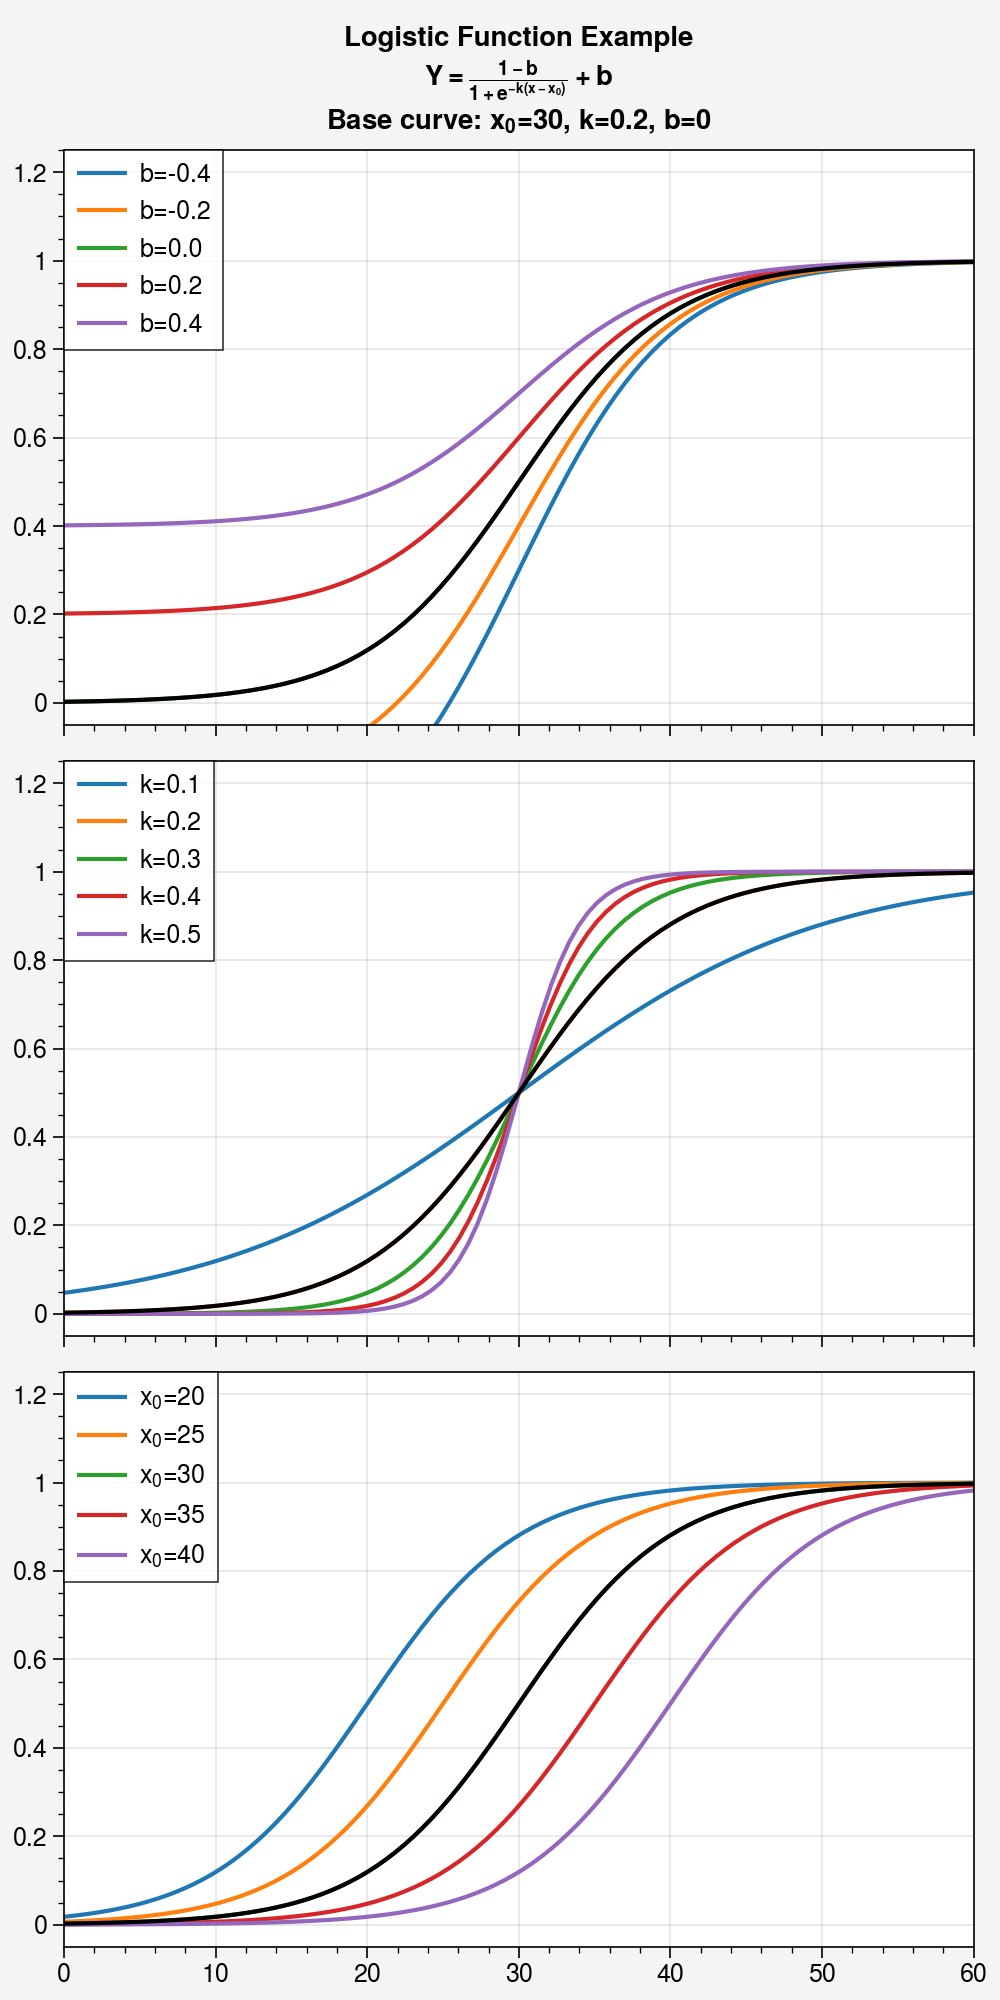

In [17]:
fig, axs = plot.subplots(figsize=(5, 10), nrows=3, ncols=1)

xx = np.linspace(0,60,100)
sel_t0 = 30
sel_b = 0
sel_k = 0.2

### varying b
BB = np.arange(-0.4, 0.41, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = logistic_fixed_upper(xx, x0=sel_t0, k=sel_k, b=b)
    axs[0].plot(xx, pred_y, label=f'b={b:.1f}', color=sel_c[i])
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying k
KK = np.arange(0.1, 0.51, 0.1)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = logistic_fixed_upper(xx, x0=sel_t0, k=k, b=sel_b)
    axs[1].plot(xx, pred_y, label=f'k={k:.1f}', color=sel_c[i])
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying t0
T0 = np.arange(20, 41, 5)
for i, t0 in enumerate(T0):
    sel_c = plot.get_colors('tab10', len(T0))
    pred_y = logistic_fixed_upper(xx, x0=t0, k=sel_k, b=sel_b)
    axs[2].plot(xx, pred_y, label=r'x$_{0}$='+f'{t0}', color=sel_c[i])
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


sel_t0 = 30
sel_k = 0.2
sel_L = 1
sel_b = 0
pred_y = logistic_fixed_upper(xx, x0=sel_t0, k=sel_k, b=sel_b)

axs.plot(xx, pred_y, label='Logistic Function', color='k')
eq_str = r'$Y = \frac{1-b}{1 + e^{-k(x -x_0)}} + b$'
text_str = r'Base curve: x$_{0}$='+f'{sel_x0}, k={sel_k}, b={sel_b}'
axs.format(
    suptitle=f'Logistic Function Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

# Performance metrics

DEBUG: use_gdgt23ratio detected
DEBUG: use_gdgt23ratio detected
DEBUG: use_gdgt23ratio detected
DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


(-0.05, 0.0)

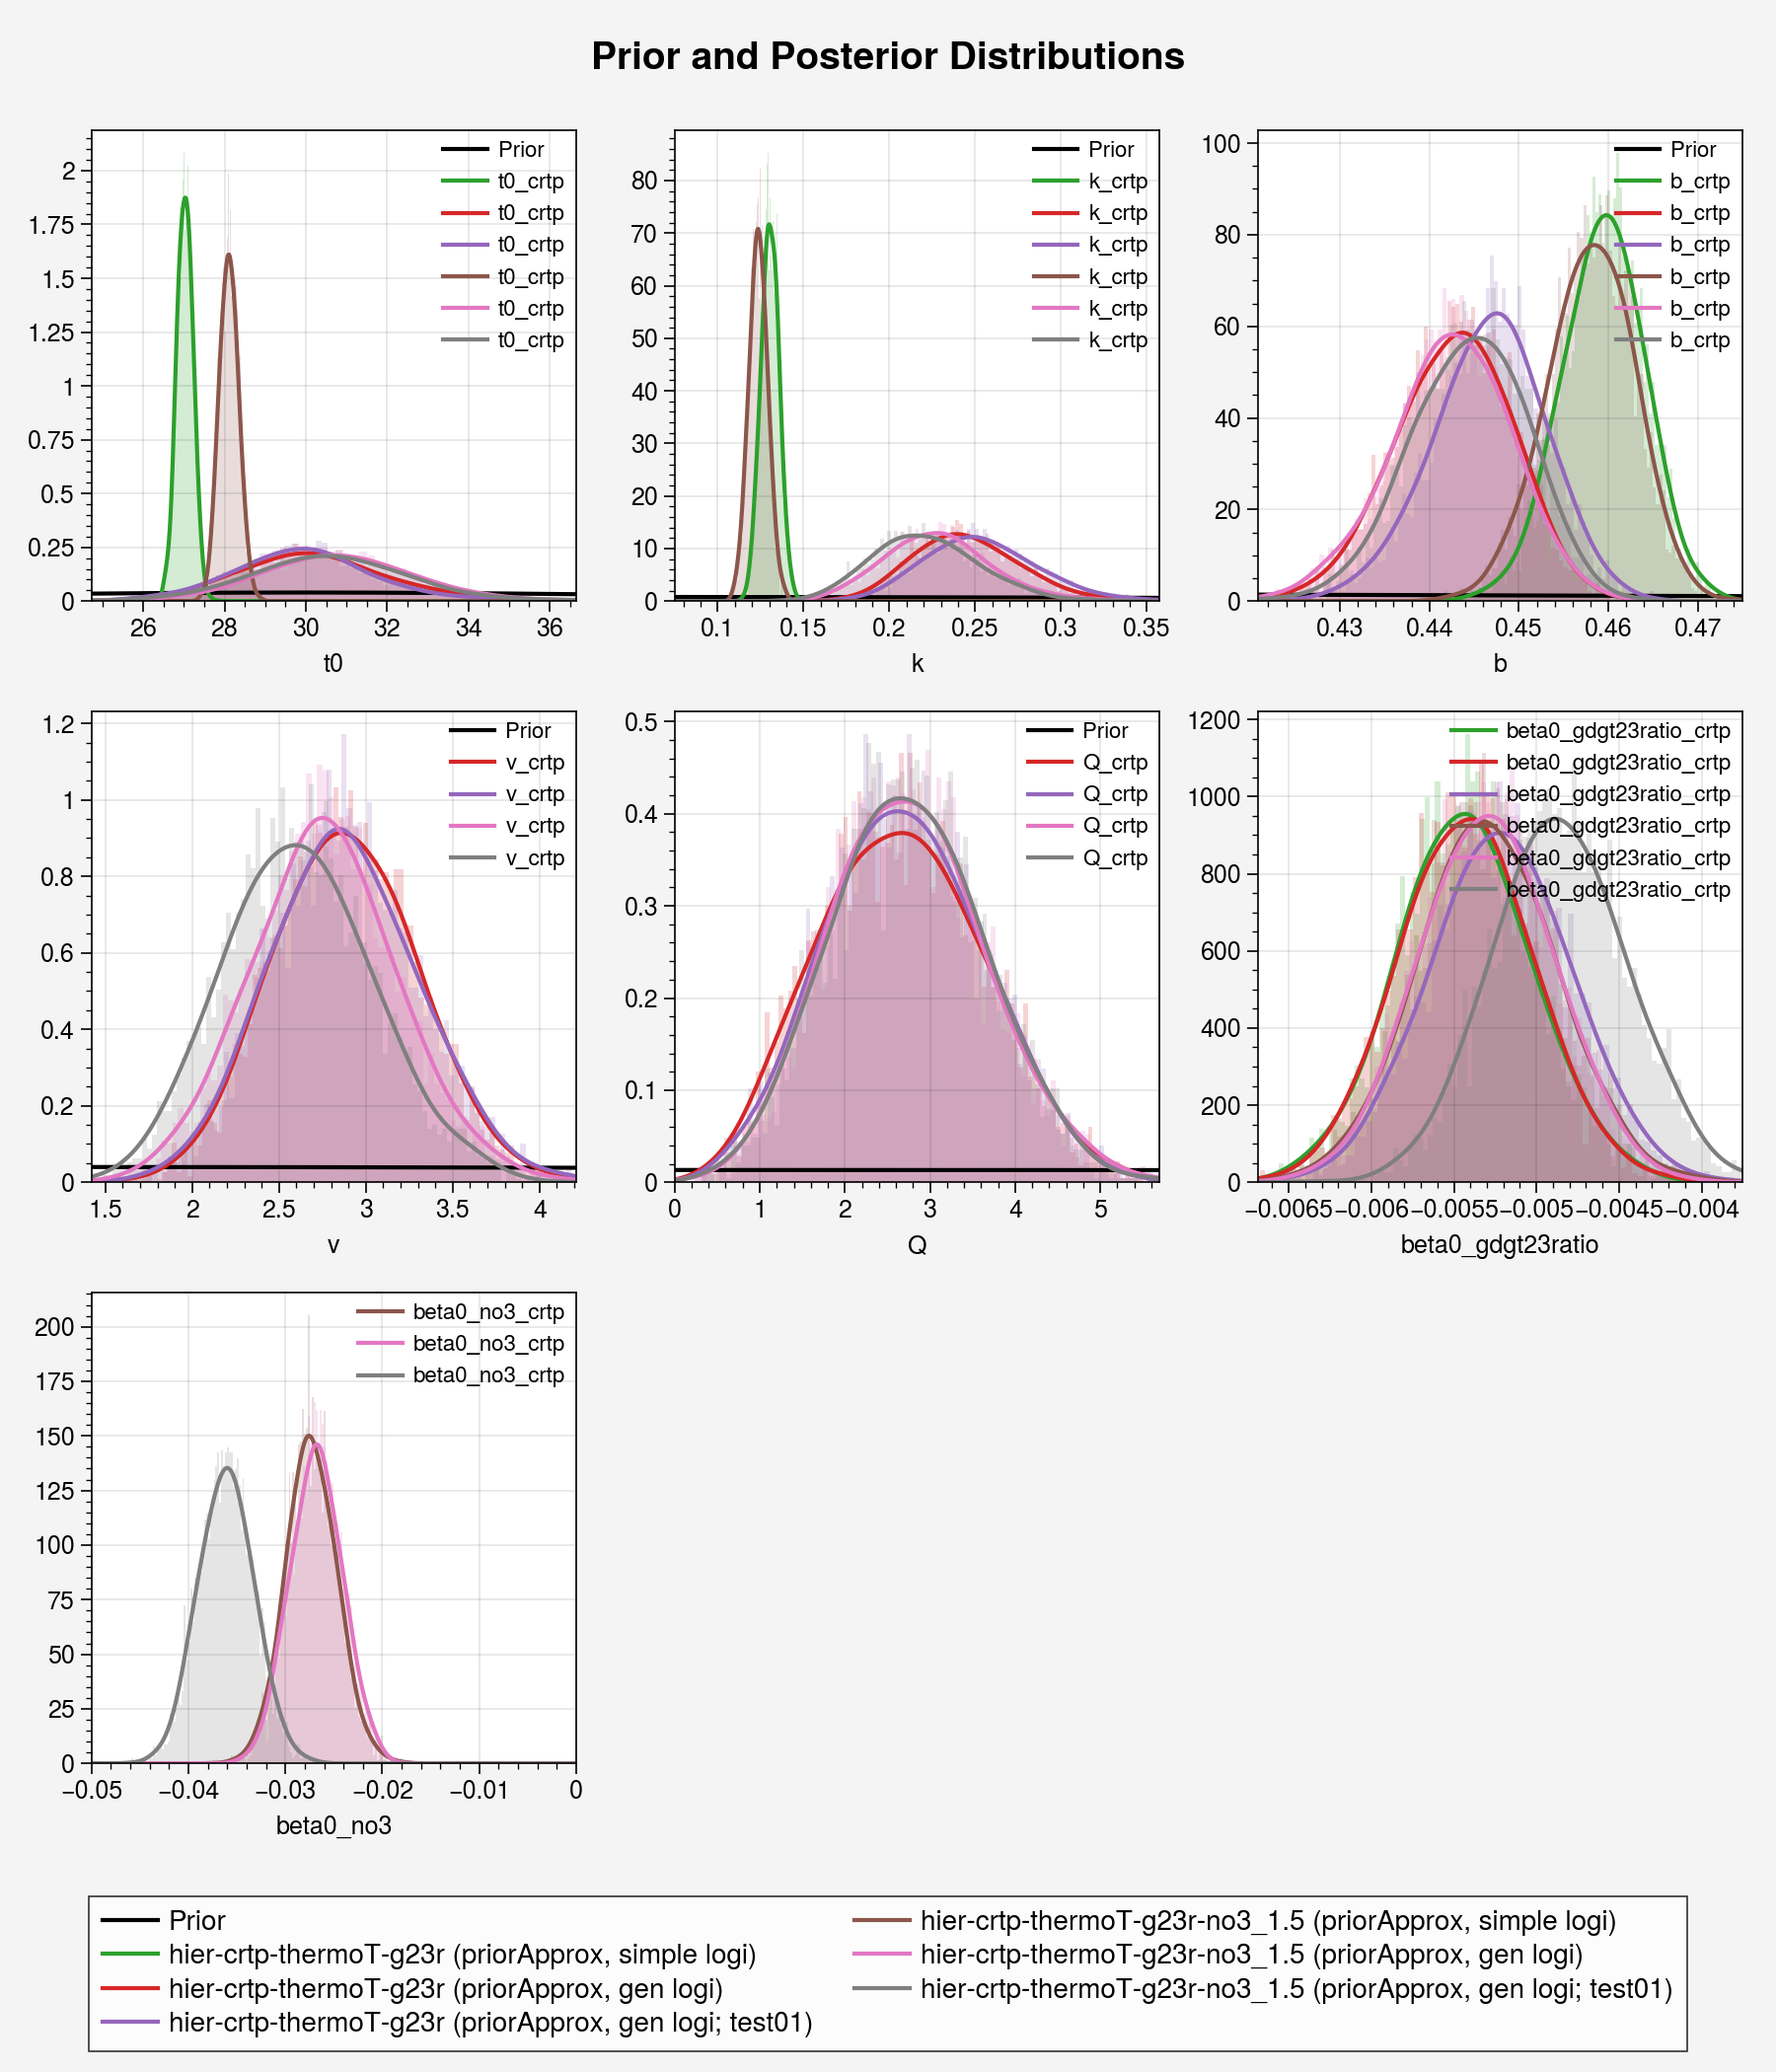

In [18]:
importlib.reload(TEXAS.plotting.prior_plot)
fig, axs = ppd.plot_prior_distributions(
    priors_list = load_posterior('gen_logi_fixed_culmeso_cultureT').attrs['priors'],
    posterior_datasets=[
        # load_posterior('jnt_cul_meso_cultureT'),
        # load_posterior('gen_logi_fixed_culmeso_cultureT'),
        # load_posterior('hier_crtp_univ_thermoT'),
        # load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT'),
        load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio'),
        load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
        load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp'),
        load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5'),
        load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5'),
        load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp')
        ],
    posterior_labels_list=[
        # 'cul-meso-cultureT (simple logi)',
        # 'cul-meso-cultureT (gen logi)',
        # 'heir-crtp-thermoT (priorApprox, simple logi)',
        # 'hier-crtp-thermoT (priorApprox, gen logi)',
        'hier-crtp-thermoT-g23r (priorApprox, simple logi)',
        'hier-crtp-thermoT-g23r (priorApprox, gen logi)',
        'hier-crtp-thermoT-g23r (priorApprox, gen logi; test01)',
        'hier-crtp-thermoT-g23r-no3_1.5 (priorApprox, simple logi)',
        'hier-crtp-thermoT-g23r-no3_1.5 (priorApprox, gen logi)',
        'hier-crtp-thermoT-g23r-no3_1.5 (priorApprox, gen logi; test01)',
    ],
    color_list=plot.get_colors('tab10',8)[-6:],
    set_leg_max_ncol=2,
    # zoomin_dataset_idx=3,
    use_linestyle_by_param=True,
    # set_fig_height_factor=3,
    suffix_include='crtp'
)

axs[2,0].set_xlim(-0.05,0)

In [19]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'combined_df_culmesocore_griddedRI.csv'
combined_df = pd.read_csv(os.path.join(fpath,fname))
combined_df = combined_df.drop(columns=['Unnamed: 0'])
combined_df

,t_sf2tc,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype
0,-1.636017,0.509982,0.413650,1.502839,NaN,coretop
1,-1.586854,0.438075,0.351000,2.833333,NaN,coretop
2,-1.692642,0.410931,0.367016,1.824832,NaN,coretop
3,-1.498910,0.433342,0.335974,2.066396,28.365620,coretop
4,-1.651191,0.447518,0.342342,2.040640,29.118933,coretop
...,...,...,...,...,...,...
1381,25.000000,0.693123,0.449778,2.629108,50.000000,mesocosm
1382,32.000000,0.656972,0.683519,3.553719,50.000000,mesocosm
1383,34.000000,0.809038,0.606766,2.318038,50.000000,mesocosm
1384,36.000000,0.899697,0.813041,2.396907,50.000000,mesocosm


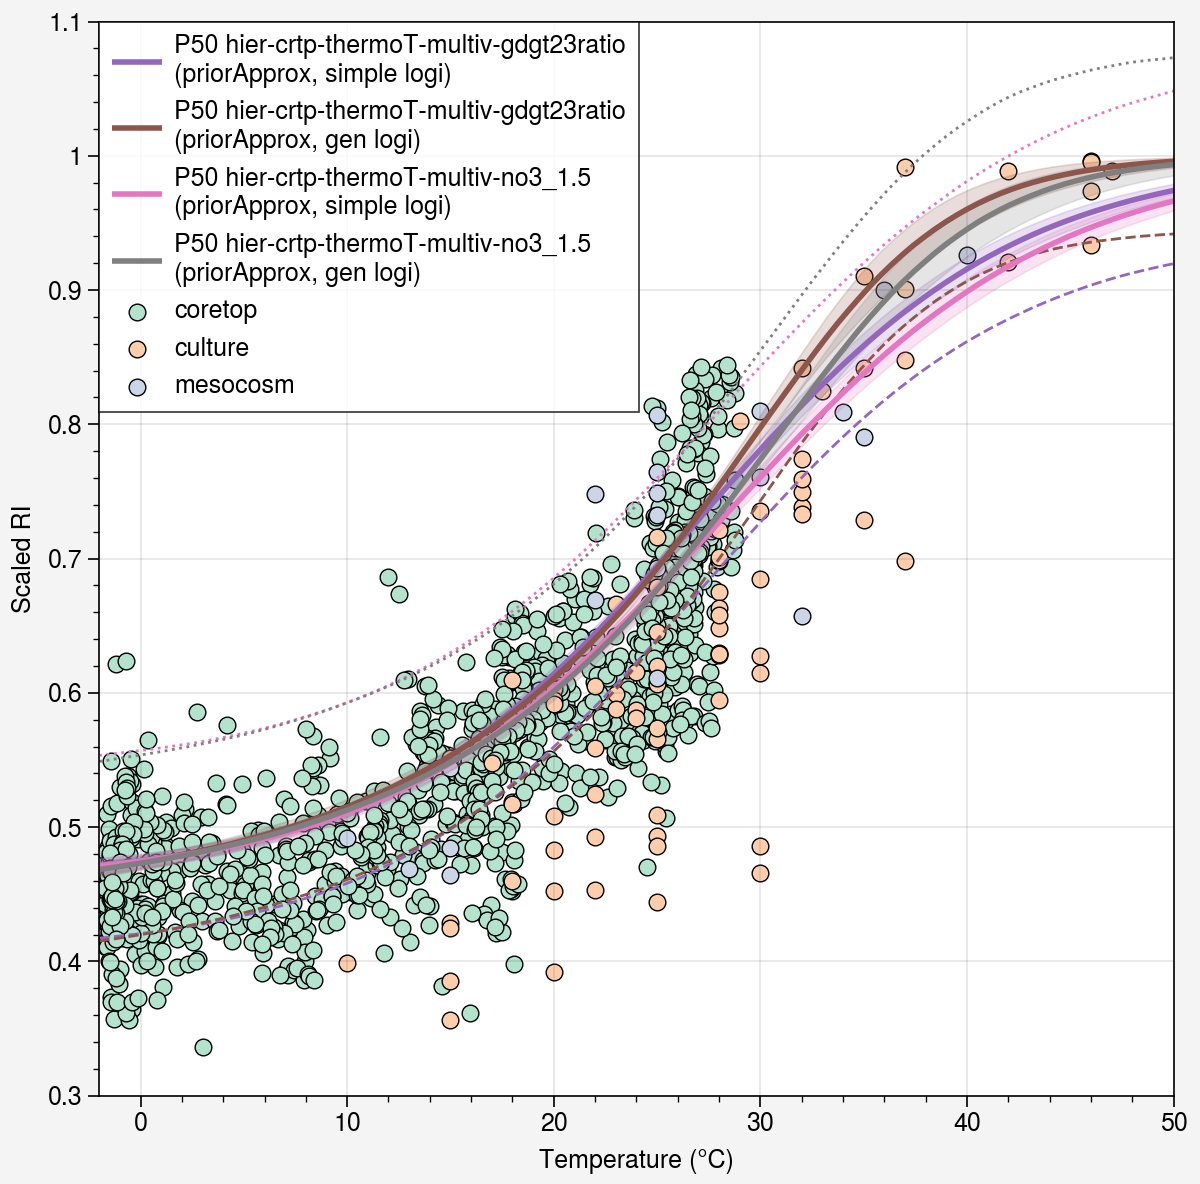

In [20]:
importlib.reload(TEXAS)
fig, ax = plot.subplots(width=6,)


grouped = combined_df.groupby('datatype')
colors = plot.get_colors('pastel2',len(grouped))
for i, (name, group) in enumerate(grouped):
    ax.scatter(group['t_sf2tc'], group['scaledRI'], 
               mec='k', mew=0.5, label=name,
               c=colors[i])



post_ds_list = [
    load_posterior('jnt_cul_meso_cultureT'),
    load_posterior('gen_logi_fixed_culmeso_cultureT'),
    load_posterior('hier_crtp_univ_thermoT'),
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT'),
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5'),
    
]
ds_labels = [
    'cul-meso-cultureT (simple logi)',
    'cul-meso-cultureT (gen logi)',
    'heir-crtp-thermoT (priorApprox, simple logi)',
    'hier-crtp-thermoT (priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, simple logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-no3_1.5\n(priorApprox, simple logi)',
    'hier-crtp-thermoT-multiv-no3_1.5\n(priorApprox, gen logi)', 
]
temperature_range = np.linspace(-2, 50, 100)
gdgt23_zeros = np.full(100, 0)  # Constant GDGT-2/3 ratio
no3_zeros = np.full(100, 0)  # No NO3 values used
gdgt23_arr = np.full(100, 10)  # Constant GDGT-2/3 ratio
no3_arr = np.full(100, 0.001)  # No NO3 values used
colors = plot.get_colors('tab10',N=len(post_ds_list))
for i, sel_post_ds in enumerate(post_ds_list):
    if i in [4,5,6,7]:
        # Generate ensemble (auto-detection)
        results = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=sel_post_ds,
            x_vals=temperature_range,
            gdgt23ratio=gdgt23_zeros,  # Required for multivariate models
            no3=no3_zeros,
            n_draws=500,
            seed=42
        )
        
        # display(results)

        # Access results
        median_pred = results['p50']        # Median prediction
        lower_bound = results['p5']         # 5th percentile
        upper_bound = results['p95']        # 95th percentile

        ax.plot(temperature_range, median_pred, 
                c=colors[i],
                # ls=['--','-'][i],
                lw=2,
                label=f'P50 {ds_labels[i]}',)
        ax.fill_between(temperature_range, lower_bound, upper_bound,
                        c=colors[i],alpha=0.2, 
                        # label=f'95% CI {sel_post_ds.attrs["filename"]}'
                        )
        
        ### 
        if 'use_gdgt23ratio' and not 'use_no3' in sel_post_ds.attrs:
            results_corrected = TEXAS.ensemble.generate_ensemble_auto(
                post_ds=sel_post_ds,
                x_vals=temperature_range,
                gdgt23ratio=gdgt23_arr,  # Required for multivariate models
                no3=no3_zeros,
                n_draws=500,
                seed=42
            )
            
            ax.plot(temperature_range,results_corrected['p50'],lw=1,ls='--',c=colors[i])
            
        if 'use_gdgt23ratio' and 'use_no3' in sel_post_ds.attrs:
            results_corrected = TEXAS.ensemble.generate_ensemble_auto(
                post_ds=sel_post_ds,
                x_vals=temperature_range,
                gdgt23ratio=gdgt23_zeros,  # Required for multivariate models
                no3=no3_arr,
                n_draws=500,
                seed=42
            )
            
            ax.plot(temperature_range,results_corrected['p50'],lw=1,ls=':',c=colors[i])
            

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='ul', ncols=1)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Scaled RI')

ax.format(
    xlim=(-2,50),
    ylim=(0.3,1.1)
)

In [21]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
from scipy.stats import gamma
### calculate gamma-weighted mean of subT from 0-200m from T_da
T_da = T_da['t_an']
T_0_200m = T_da.sel(depth=slice(0,200))

# 1) grab your depth coordinate
depth = T_0_200m["depth"].values  

# 2) compute the gamma PDF at each depth
a = 4.5       # shape
scale = 15.0  # scale (this is your “b”)
pdf = gamma.pdf(depth, a, scale=scale)

w = xr.DataArray(
    pdf,
    coords={"depth": T_0_200m.depth},
    dims=("depth",),
    name="gamma_wt"
)

T_0_200m_gamma_mean = T_0_200m.weighted(w).mean(dim="depth")
T_0_200m_gamma_mean = T_0_200m_gamma_mean.rename('subT_gamma_mean_200m')
T_0_200m_linear_mean = T_0_200m.mean(dim="depth")
T_0_200m_linear_mean = T_0_200m_linear_mean.rename('subT_linear_mean_200m')

In [22]:
coretop_df['gamma200m_subT'] = np.nan
coretop_df['linear200m_subT'] = np.nan
for i in range(len(coretop_df)):
    match_lat = coretop_df.loc[i,'lat']
    match_lon = coretop_df.loc[i,'lon']
    coretop_df.loc[i,'gamma200m_subT'] = T_0_200m_gamma_mean.sel(
        lat=match_lat,lon=match_lon,method='nearest').values[0]
    
    coretop_df.loc[i,'linear200m_subT'] = T_0_200m_linear_mean.sel(
        lat=match_lat,lon=match_lon,method='nearest').values[0]
    

In [23]:
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI,gamma200m_subT,linear200m_subT
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584,-1.792284,-1.781117
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499,-1.697924,-1.698429
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510,-1.850852,-1.827474
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747,-1.727918,-1.700938
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210,-1.804541,-1.786992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001,-1.052247,-0.689160
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673,-1.559954,-1.195832
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930,-1.559690,-1.434368
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832,-1.684744,-1.395399


# Model evaluation

In [24]:
plot_data = coretop_df

TEX_models = ['schouten02','kim2010_tex86H']
for method in TEX_models:
    plot_data[f'predTEX_{method}-sst'] = predictTEXfromSST(plot_data['sst'])
    plot_data[f'predT_{method}-sst'] = predictSSTfromTEX(plot_data['tex_median'])
    
    plot_data[f'TEXres_{method}-sst'] = plot_data['tex_median'] - plot_data[f'predTEX_{method}-sst']
    plot_data[f'Tres_{method}-sst'] = plot_data['sst'] - plot_data[f'predT_{method}-sst']
    

plot_data

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gamma200m_subT,linear200m_subT,predTEX_schouten02-sst,predT_schouten02-sst,TEXres_schouten02-sst,Tres_schouten02-sst,predTEX_kim2010_tex86H-sst,predT_kim2010_tex86H-sst,TEXres_kim2010_tex86H-sst,Tres_kim2010_tex86H-sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,-1.792284,-1.781117,0.257972,12.377672,0.155677,-14.026082,0.257972,12.377672,0.155677,-14.026082
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,-1.697924,-1.698429,0.259200,7.499007,0.091800,-9.006417,0.259200,7.499007,0.091800,-9.006417
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,-1.850852,-1.827474,0.257510,8.824437,0.109506,-10.526147,0.257510,8.824437,0.109506,-10.526147
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,-1.727918,-1.700938,0.259891,6.199317,0.076083,-7.627627,0.259891,6.199317,0.076083,-7.627627
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,-1.804541,-1.786992,0.257102,6.757097,0.085240,-8.505908,0.257102,6.757097,0.085240,-8.505908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,-1.052247,-0.689160,0.259356,9.304884,0.113644,-10.794394,0.259356,9.304884,0.113644,-10.794394
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,-1.559954,-1.195832,0.258042,6.024258,0.075958,-7.664668,0.258042,6.024258,0.075958,-7.664668
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,-1.559690,-1.434368,0.258638,14.076829,0.179362,-15.648629,0.258638,14.076829,0.179362,-15.648629
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,-1.684744,-1.395399,0.257233,18.009548,0.242767,-19.743258,0.257233,18.009548,0.242767,-19.743258


In [ ]:
plot_data['predTEX_BAYSPAR-sst'] = np.nan
plot_data['predT_BAYSPAR-sst'] = np.nan
for i in tqdm(range(len(plot_data))):
    plot_data['predTEX_BAYSPAR-sst'].iloc[i] = bsr.predict_tex(np.atleast_1d(plot_data['sst'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           temptype='sst').percentile(50)[0]

    plot_data['predT_BAYSPAR-sst'].iloc[i] = bsr.predict_seatemp(np.atleast_1d(plot_data['tex_median'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           prior_std=6,
                                                           temptype='sst').percentile(50)[0]
    
plot_data['TEXres_BAYSPAR-sst'] = plot_data['tex_median'] - plot_data['predTEX_BAYSPAR-sst']
plot_data['Tres_BAYSPAR-sst'] = plot_data['sst'] - plot_data['predT_BAYSPAR-sst']

plot_data['predTEX_BAYSPAR-subt'] = np.nan
plot_data['predT_BAYSPAR-subt'] = np.nan
for i in tqdm(range(len(plot_data))):
    plot_data['predTEX_BAYSPAR-subt'].iloc[i] = bsr.predict_tex(np.atleast_1d(plot_data['gamma200m_subT'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           temptype='subt').percentile(50)[0]

    plot_data['predT_BAYSPAR-subt'].iloc[i] = bsr.predict_seatemp(np.atleast_1d(plot_data['tex_median'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           prior_std=6,
                                                           temptype='subt').percentile(50)[0]
    
plot_data['TEXres_BAYSPAR-subt'] = plot_data['tex_median'] - plot_data['predTEX_BAYSPAR-subt']
plot_data['Tres_BAYSPAR-subt'] = plot_data['gamma200m_subT'] - plot_data['predT_BAYSPAR-subt']
plot_data

In [26]:
plot_data['predRI_sim_logi_T-sst'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_sim_logi_T-sst'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst']

plot_data['predRI_T-sst'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_T-sst'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst']

plot_data['predRI_T-sst_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_T-sst_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst_new']
###############################################
plot_data['predRI_sim_logi_T-sst-g23r'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'])['p50']
plot_data['RIres_sim_logi_T-sst-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst-g23r']

plot_data['predRI_T-sst-g23r'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-sst-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r']

plot_data['predRI_T-sst-g23r_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-g23r_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r_new']
###############################################
plot_data['predRI_sim_logi_T-sst-g23r-no3'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-sst-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst-g23r-no3']

plot_data['predRI_T-sst-g23r-no3'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-sst-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r-no3']

plot_data['predRI_T-sst-g23r-no3_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-g23r-no3_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r-no3_new']

In [27]:
plot_data['predRI_sim_logi_T-thermoT'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_priorApprox_thermoT'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-thermoT'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT']

plot_data['predRI_T-thermoT'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT']

plot_data['predRI_T-thermoT_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT_new']
###############################################
plot_data['predRI_sim_logi_T-thermoT-g23r'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'])['p50']
plot_data['RIres_sim_logi_T-thermoT-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT-g23r']

plot_data['predRI_T-thermoT-g23r'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-thermoT-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r']

plot_data['predRI_T-thermoT-g23r_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-g23r_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r_new']
###############################################
plot_data['predRI_sim_logi_T-thermoT-g23r-no3'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-thermoT-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT-g23r-no3']

plot_data['predRI_T-thermoT-g23r-no3'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r-no3']

plot_data['predRI_T-thermoT-g23r-no3_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-g23r-no3_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r-no3_new']

In [29]:
temptype = 'thermoT'
sel_temp_param = 't_sf2tc_avg'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5_test01_cln_crtp',
    ]

new_col_names = [
    f'predT_sim_logi_T-{temptype}_marginal',
    f'predT_T-{temptype}_marginal',
    f'predT_T-{temptype}_new_marginal',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio_marginal',
    f'predT_T-{temptype}-gdgt23ratio_marginal',
    f'predT_T-{temptype}-gdgt23ratio_new_marginal',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio-no3_marginal',
    f'predT_T-{temptype}-gdgt23ratio-no3_marginal',
    f'predT_T-{temptype}-gdgt23ratio-no3_new_marginal',
]

for i, (fwd_posterior_name, col_name) in enumerate(zip(fwd_posterior_list, new_col_names)):
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']) &
                      pd.notna(plot_data['no3_sf2tc_avg']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']))
    else:
        nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
        prior_mu_t=plot_data.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
        predictors={
                'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
                'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
            },
        use_marginal=True
    )
    plot_data.loc[nonnan_idx, col_name] = results_dict['p50']

06:48:16 - cmdstanpy - INFO - compiling stan file /home/micromamba/app/TEXAS/stan_models/invT_logistic_fixed_univ_marginal.stan to exe file /home/micromamba/app/TEXAS/stan_models/invT_logistic_fixed_univ_marginal


Found 1282 valid rows out of 1286
🔍 Automatically selected Stan file: invT_logistic_fixed_univ_marginal.stan
| M=100 N=1282
🔧 Compiling Stan model: invT_logistic_fixed_univ_marginal.stan


06:48:33 - cmdstanpy - INFO - compiled model executable: /home/micromamba/app/TEXAS/stan_models/invT_logistic_fixed_univ_marginal
06:48:33 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_logistic_fixed_univ_marginal.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

06:57:15 - cmdstanpy - INFO - CmdStan done processing.


NameError: name 'runtime' is not defined

In [ ]:
temptype = 'thermoT'
sel_temp_param = 't_sf2tc_avg'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5_test01_cln_crtp',
    ]

new_col_names = [
    f'predT_sim_logi_T-{temptype}',
    f'predT_T-{temptype}',
    f'predT_T-{temptype}_new',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio',
    f'predT_T-{temptype}-gdgt23ratio',
    f'predT_T-{temptype}-gdgt23ratio_new',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio-no3',
    f'predT_T-{temptype}-gdgt23ratio-no3',
    f'predT_T-{temptype}-gdgt23ratio-no3_new',
]

for i, (fwd_posterior_name, col_name) in enumerate(zip(fwd_posterior_list, new_col_names)):
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']) &
                      pd.notna(plot_data['no3_sf2tc_avg']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']))
    else:
        nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
        prior_mu_t=plot_data.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
        predictors={
                'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
                'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
            }
    )
    plot_data.loc[nonnan_idx, col_name] = results_dict['p50']

05:31:09 - cmdstanpy - INFO - CmdStan start processing


Found 1282 valid rows out of 1286
🔍 Automatically selected Stan file: invT_logistic_fixed_univ
| M=100 N=1282


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

KeyboardInterrupt: 

06:34:31 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 9 Unknown error -9
06:34:31 - cmdstanpy - ERROR - Chain [2] error: terminated by signal 9 Unknown error -9
06:34:31 - cmdstanpy - ERROR - Chain [3] error: terminated by signal 9 Unknown error -9
06:34:31 - cmdstanpy - ERROR - Chain [4] error: terminated by signal 9 Unknown error -9
--- Logging error ---
Traceback (most recent call last):
  File "/opt/conda/envs/texas-env/lib/python3.10/logging/__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "/opt/conda/envs/texas-env/lib/python3.10/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/opt/conda/envs/texas-env/lib/python3.10/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/opt/conda/envs/texas-env/lib/python3.10/site-packages/ipykernel/iostream.py", line 267, in schedule
    self._event_pipe.send(b"")
  File "/opt/conda/env

In [ ]:
temptype = 'sst'
sel_temp_param = 'sst'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5_test01_cln_crtp',
    ]

new_col_names = [
    f'predT_sim_logi_T-{temptype}_marginal',
    f'predT_T-{temptype}_marginal',
    f'predT_T-{temptype}_new_marginal',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio_marginal',
    f'predT_T-{temptype}-gdgt23ratio_marginal',
    f'predT_T-{temptype}-gdgt23ratio_new_marginal',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio-no3_marginal',
    f'predT_T-{temptype}-gdgt23ratio-no3_marginal',
    f'predT_T-{temptype}-gdgt23ratio-no3_new_marginal',
]

for i, (fwd_posterior_name, col_name) in enumerate(zip(fwd_posterior_list, new_col_names)):
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']) &
                      pd.notna(plot_data['no3_sf2tc_avg']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']))
    else:
        nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
        prior_mu_t=plot_data.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
        predictors={
                'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
                'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
            },
        use_marginal=True
    )
    plot_data.loc[nonnan_idx, col_name] = results_dict['p50']

In [ ]:
temptype = 'sst'
sel_temp_param = 'sst'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_no3_1.5_test01_cln_crtp',
    ]

new_col_names = [
    f'predT_sim_logi_T-{temptype}',
    f'predT_T-{temptype}',
    f'predT_T-{temptype}_new',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio',
    f'predT_T-{temptype}-gdgt23ratio',
    f'predT_T-{temptype}-gdgt23ratio_new',
    f'predT_sim_logi_T-{temptype}-gdgt23ratio-no3',
    f'predT_T-{temptype}-gdgt23ratio-no3',
    f'predT_T-{temptype}-gdgt23ratio-no3_new',
]

for i, (fwd_posterior_name, col_name) in enumerate(zip(fwd_posterior_list, new_col_names)):
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']) &
                      pd.notna(plot_data['no3_sf2tc_avg']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(plot_data['scaledRI_median']) &
                      pd.notna(plot_data[sel_temp_param]) &
                      pd.notna(plot_data['gdgt23ratio_median']))
    else:
        nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
        prior_mu_t=plot_data.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
            predictors={
                'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
                'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
            }
    )
    plot_data.loc[nonnan_idx, col_name] = results_dict['p50']

In [ ]:
# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data['sst'])

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_univ_priorApprox_sst',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

# #######################################################################################

# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data['sst'])

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_Tonly_new'] = results_dict['p50']

# #######################################################################################

# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data['sst']) & pd.notna(plot_data['gdgt23ratio_median'])

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True,
#         predictors={
#             'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
#             # 'no3': plot_data['no3_sf2tc_avg'].values
#         }
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_T-g23r'] = results_dict['p50']

# #######################################################################################

# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = pd.notna(plot_data['scaledRI_median']) & pd.notna(plot_data['sst']) & pd.notna(plot_data['gdgt23ratio_median'])

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True,
#         predictors={
#             'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
#             # 'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
#         }
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_T-g23r_new'] = results_dict['p50']

# #######################################################################################

# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = (pd.notna(plot_data['scaledRI_median']) 
#               & pd.notna(plot_data['sst']) 
#               & pd.notna(plot_data['gdgt23ratio_median']) 
#               & pd.notna(plot_data['no3_sf2tc_avg']))

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True,
#         predictors={
#             'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
#             'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
#         }
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_T-g23r-no3'] = results_dict['p50']

# #######################################################################################

# # 1. Create a boolean mask for rows where BOTH columns are valid
# nonnan_idx = (pd.notna(plot_data['scaledRI_median']) 
#               & pd.notna(plot_data['sst']) 
#               & pd.notna(plot_data['gdgt23ratio_median']) 
#               & pd.notna(plot_data['no3_sf2tc_avg']))

# # You can see how many valid rows you have:
# print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# # 2. Use the mask to select clean data for the model
# # .loc[nonnan_idx] selects only the rows where the index is True
# results_dict = TEXAS.stan.predict_temperature_from_RI(
#     scaledRI=plot_data.loc[nonnan_idx, 'scaledRI_median'].astype(float).tolist(),
#     prior_mu_t=plot_data.loc[nonnan_idx, 'sst'].values,
#     prior_sigma_t=6,
#     fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp',
#     site_name='global-coretop',
#     temptype='sst',
#     iter_warmup=200,
#     iter_sampling=500,
#     save_results=True,
#         predictors={
#             'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio_median'].values,
#             'no3': plot_data.loc[nonnan_idx, 'no3_sf2tc_avg'].values
#         }
# )

# # 3. Assign the results back to the original dataframe in the correct spots
# # This works because the boolean index aligns the results perfectly.
# plot_data.loc[nonnan_idx, 'predSST_T-g23r-no3_new'] = results_dict['p50']

# #######################################################################################

# methods = ['Tonly','T-g23r','T-g23r-no3','Tonly_new','T-g23r_new','T-g23r-no3_new']
# for method in methods:
#     plot_data[f'SSTres_{method}'] = plot_data['sst'] - plot_data[f'predSST_{method}']
    
# plot_data

In [ ]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'gridded_coretop_with_logi_predRI_T_2025-08-19.csv'

plot_data = pd.read_csv(os.path.join(fpath,fname))
plot_data = plot_data.iloc[:,1:]
plot_data

In [ ]:
fig, axs = plot.subplots(proj='eck3',ncols=2,nrows=3,width=8,wspace=3)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)

plot_data = plot_data.dropna(how='any',subset=['t_sf2tc_avg','sst',
                                               'gdgt23ratio_median',
                                               'no3_sf2tc_avg','tex_median',
                                               'scaledRI_median']) 
plot_x = plot_data['lon']
plot_y = plot_data['lat']

methods = ['schouten02','kim2010_tex86H','BAYSPAR']
for i, method in enumerate(methods):
    plot_c = plot_data[f'TEXres_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-0.3,0.31,0.05),
                        zorder=2,mec='k')
    
    
    ### RMSE calculation
    rmse_tex_ = np.sqrt(mean_squared_error(plot_data['tex_median'],plot_data[f'predTEX_{method}']))
    
    axs[i,0].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.95, 0.87, f"{rmse_tex_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_c = plot_data[f'SSTres_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-10,10.1,2),
                        zorder=2,mec='k')
    
    ### RMSE calculation
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'],plot_data[f'predSST_{method}']))
    axs[i,1].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.95, 0.87, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )



axs[-1,0].colorbar(m1,loc='b')
axs[-1,1].colorbar(m2,loc='b')

axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['Schouten2002','Kim2010_TEX86H','BAYSPAR']
)

In [ ]:
fig, axs = plot.subplots(ncols=2,nrows=3,width=6,share=0)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


methods = ['schouten02','kim2010_tex86H','BAYSPAR']
for i, method in enumerate(methods):
    plot_x = plot_data['tex_median']
    plot_y = plot_data[f'predTEX_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['tex_median']) & ~np.isnan(plot_data[f'predTEX_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['tex_median'][nonnan_idx],plot_data[f'predTEX_{method}'][nonnan_idx]))

    axs[i,0].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.05, 0.89, f"{rmse_RI_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_x = plot_data['sst']
    plot_y = plot_data[f'predSST_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['sst']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[i,1].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.05, 0.89, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )


axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['schouten02','kim2010_tex86H','BAYSPAR']
)

axs[:-1,:].format(xlabel='')

axs[:,0].plot([0.2,0.9],[0.2,0.9],c='gray5',zorder=0)
axs[:,0].format(xlim=(0.2,0.9),xticks=np.arange(0.2,0.81,0.2),
                ylim=(0.2,0.9),ylabel='predTEX')

axs[:,1].plot([-5,40],[-5,40],c='gray5',zorder=0)
axs[:,1].format(xlim=(-5,40),ylim=(-5,40),ylabel='predSST')

In [ ]:
fig, axs = plot.subplots(proj='eck3',ncols=2,nrows=3,width=8,wspace=3)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


plot_x = plot_data['lon']
plot_y = plot_data['lat']

methods = ['Tonly','T-g23r','T-g23r-no3']
for i, method in enumerate(methods):
    plot_c = plot_data[f'RIres_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-0.3,0.31,0.05),
                        zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['scaledRI_median']) & ~np.isnan(plot_data[f'predRI_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['scaledRI_median'][nonnan_idx],plot_data[f'predRI_{method}'][nonnan_idx]))

    axs[i,0].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.95, 0.87, f"{rmse_RI_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_c = plot_data[f'SSTres_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-10,10.1,2),
                        zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['sst']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[i,1].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.95, 0.87, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )


axs[-1,0].colorbar(m1,loc='b')
axs[-1,1].colorbar(m2,loc='b')

axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['Tonly','T-g23r','T-g23r-no3']
)

In [ ]:
fig, axs = plot.subplots(ncols=2,nrows=3,width=6,share=0)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


methods = ['Tonly','T-g23r','T-g23r-no3']
for i, method in enumerate(methods):
    plot_x = plot_data['scaledRI_median']
    plot_y = plot_data[f'predRI_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['scaledRI_median']) & ~np.isnan(plot_data[f'predRI_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['scaledRI_median'][nonnan_idx],plot_data[f'predRI_{method}'][nonnan_idx]))

    axs[i,0].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.05, 0.89, f"{rmse_RI_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_x = plot_data['sst']
    plot_y = plot_data[f'predSST_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['sst']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[i,1].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.05, 0.89, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )


axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['Tonly','T-g23r','T-g23r-no3']
)

axs[:-1,:].format(xlabel='')

axs[:,0].plot([0.2,0.9],[0.2,0.9],c='gray5',zorder=0)
axs[:,0].format(xlim=(0.2,0.9),xticks=np.arange(0.2,0.81,0.2),
                ylim=(0.2,0.9),ylabel='predRI')

axs[:,1].plot([-5,40],[-5,40],c='gray5',zorder=0)
axs[:,1].format(xlim=(-5,40),ylim=(-5,40),ylabel='predSST')

In [ ]:
fig, axs = plot.subplots(proj='eck3',ncols=2,nrows=3,width=8,wspace=3)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


plot_x = plot_data['lon']
plot_y = plot_data['lat']

methods = ['Tonly_new','T-g23r_new','T-g23r-no3_new']
for i, method in enumerate(methods):
    plot_c = plot_data[f'RIres_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-0.3,0.31,0.05),
                        zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['scaledRI_median']) & ~np.isnan(plot_data[f'predRI_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['scaledRI_median'][nonnan_idx],plot_data[f'predRI_{method}'][nonnan_idx]))

    axs[i,0].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.95, 0.87, f"{rmse_RI_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_c = plot_data[f'SSTres_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,c=plot_c,s=20,
                        levels=np.arange(-10,10.1,2),
                        zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['sst']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[i,1].text(
        0.95, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.95, 0.87, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )


axs[-1,0].colorbar(m1,loc='b')
axs[-1,1].colorbar(m2,loc='b')

axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['Tonly (cln_crtp)','T-g23r (cln_crtp)','T-g23r-no3 (cln_crtp)']
)

In [ ]:
fig, axs = plot.subplots(ncols=2,nrows=3,width=6,share=0)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


methods = ['Tonly_new','T-g23r_new','T-g23r-no3_new']
for i, method in enumerate(methods):
    plot_x = plot_data['scaledRI_median']
    plot_y = plot_data[f'predRI_{method}']
    m1 = axs[i,0].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['scaledRI_median']) & ~np.isnan(plot_data[f'predRI_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['scaledRI_median'][nonnan_idx],plot_data[f'predRI_{method}'][nonnan_idx]))

    axs[i,0].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,0].text(
        0.05, 0.89, f"{rmse_RI_:.3f}", 
        transform=axs[i,0].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_x = plot_data['sst']
    plot_y = plot_data[f'predSST_{method}']
    m2 = axs[i,1].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['sst']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['sst'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[i,1].text(
        0.05, 0.95, "RMSE", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[i,1].text(
        0.05, 0.89, f"{rmse_sst_:.3f}", 
        transform=axs[i,1].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )


axs.format(
    collabels=['Proxy residuals','T residuals'],
    rowlabels=['Tonly (test01)','T-g23r (test01)','T-g23r-no3 (test01)']
)

axs[:-1,:].format(xlabel='')

axs[:,0].plot([0.2,0.9],[0.2,0.9],c='gray5',zorder=0)
axs[:,0].format(xlim=(0.2,0.9),xticks=np.arange(0.2,0.81,0.2),
                ylim=(0.2,0.9),ylabel='predRI')
axs[:,1].plot([-5,40],[-5,40],c='gray5',zorder=0)
axs[:,1].format(xlim=(-5,40),ylim=(-5,40),ylabel='predSST')

In [ ]:
current_date = date.today()
fpath = f'{local_github_path}/spreadsheets/gridded_coretop_with_logi_predRI_T_{current_date}.csv'
plot_data.to_csv(fpath)

In [ ]:
importlib.reload(TEXAS.ensemble)
fig, axs = plot.subplots(ncols=2,nrows=4)

post_ds_list = [
    load_posterior('jnt_cul_meso_cultureT'),
    load_posterior('gen_logi_fixed_culmeso_cultureT'),
    load_posterior('hier_crtp_univ_thermoT_test01_cln_crtp'),
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp'),
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp'),
    
]
ds_labels = [
    'cul-meso-cultureT (simple logi)',
    'cul-meso-cultureT (gen logi)',
    'heir-crtp-thermoT (priorApprox, simple logi)',
    'hier-crtp-thermoT (priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, simple logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-no3_1.5\n(priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-no3_1.5\n(priorApprox, gen logi - test01)', 
]

temperature_range = np.linspace(-2, 50, 100)
gdgt23_ratio = np.full(100, 5)  # Constant GDGT-2/3 ratio
no3_vals = np.full(100, 1e-3)  # No NO3 values used
colors = plot.get_colors('tab10',N=len(post_ds_list))

plot_data = combined_df.dropna(how='any',subset=['t_sf2tc','gdgt23ratio','no3_sf2tc'])

ii = 0
for i, sel_post_ds in enumerate(post_ds_list):
    if i in [0,1,2,3,4,5,6,7]:
        ax = axs[ii]
        ii += 1
        ax.format(
            title=ds_labels[i]
        )
        
        plot_data['predRI'] = TEXAS.ensemble.generate_ensemble_auto(
                    post_ds=sel_post_ds,
                    x_vals=plot_data['t_sf2tc'],
                    gdgt23ratio=plot_data['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
                    no3=plot_data['no3_sf2tc'], # if 'use_no3' in sel_post_ds.attrs else np.full(len(plot_data),0), 
                    no3_cutoff=1.5,
                    n_draws=500,
                    seed=42
                )['p50']

        plot_x = plot_data['scaledRI']
        plot_y = plot_data['predRI']
        nonnan_idx = ~plot_x.isnull() & ~plot_y.isnull()

        ax.scatter(plot_x[nonnan_idx],plot_y[nonnan_idx],m='.',c=colors[i])
        
        # pearson r and pval
        nonnan_idx = ~plot_x.isnull() & ~plot_y.isnull()
        _r, _pval = pearsonr(plot_x[nonnan_idx],plot_y[nonnan_idx])
        pval_label = label_pvalues(_pval)
        ax.format(
            ultitle=f"Pearson'r = {_r:.3f}\n{pval_label}"
        )
        
        culmeso_data = plot_data[plot_data['datatype']!='coretop']
        plot_x2 = culmeso_data['scaledRI']
        plot_y2 = culmeso_data['predRI']
        ax.scatter(plot_x2,plot_y2,
                   m='o',facecolor='none',mec='k')
        

axs.plot([0.3,1],[0.3,1],c='gray5',zorder=0)
axs.format(
    suptitle='Predict RI from T (forward models)',
    xlabel='Observed RI',ylabel='Predicted RI',
    # xlim=(0.3,1),ylim=(0.3,1)
    
    ### zoom in axis
    xlim=(0.6,1),ylim=(0.6,1),
    )


In [ ]:
def find_strongest_neg_corr_threshold(
    df,
    x_col,
    y_col,
    window_size_range=np.arange(5, 101, 1),
    min_valid=5,
    verbose=False,
):
    """
    Find x threshold for x< threshold that gives the strongest negative Spearman
    correlation between x and y, varying binning window size for running mean.
    
    Returns:
        dict with:
            - threshold: float
            - rho: float
            - window_size: int
            - xx_rolling: array (linear x, best window)
            - yy_rolling: array (y rolling mean, best window)
            - all_rhos, all_thresholds, all_window_sizes
    """
    df = df.sort_values(by=x_col).reset_index(drop=True)
    best_rho = None
    best_threshold = None
    best_window_size = None
    best_xx_rolling = None
    best_yy_rolling = None

    score_list = []
    pval_list = []
    threshold_list = []

    for window_size in window_size_range:
        log_x, y_running_mean = running_mean_log10(df[x_col], df[y_col], window_size)
        idx_min = y_running_mean.idxmin()
        try:
            threshold = 10 ** log_x[idx_min]
        except Exception:
            continue
        reg_data = df[df[x_col] < threshold]
        if len(reg_data) < min_valid:
            score_list.append(np.nan)
            pval_list.append(np.nan)
            threshold_list.append(np.nan)
            continue
        rho, pval = spearmanr(reg_data[x_col], reg_data[y_col])
        score_list.append(rho)
        pval_list.append(pval)
        threshold_list.append(threshold)
        if (best_rho is None) or (rho < best_rho):
            best_rho = rho
            best_threshold = threshold
            best_window_size = window_size
            best_xx_rolling = 10 ** log_x
            best_yy_rolling = y_running_mean
            if verbose:
                print(f"Window {window_size}: threshold={threshold:.2g}, rho={rho:.3f}, N={len(reg_data)}")
    return {
        "threshold": best_threshold,
        "rho": best_rho,
        "window_size": best_window_size,
        "xx_rolling": best_xx_rolling,
        "yy_rolling": best_yy_rolling,
        "all_rhos": np.array(score_list),
        "all_thresholds": np.array(threshold_list),
        "all_window_sizes": window_size_range
    }

def running_mean_log10(x, y, window_size):
        # Convert x to log10 scale
        log_x = np.log10(x)
        
        # Create a DataFrame with log_x and y
        df = pd.DataFrame({'log_x': log_x, 'y': y})
        
        # Sort the DataFrame by log_x
        df = df.sort_values(by='log_x')
        
        # Calculate the running mean of y with the specified window size
        df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
        
        return df['log_x'], df['y_running_mean']


In [ ]:
def calculate_deltaRI_from_scaledRI(
    tex: np.array,
    scaled_ri: np.array,
    method: str = 'zhang16'
) -> np.array:
    
    if method == 'zhang16':
       tex_ri =  -0.77*tex + 3.32*(tex**2) + 1.59
       delta_ri = tex_ri - scaled_ri*4
       
    if method == 'ln_this_study':
        tex_ri = np.exp(1.4312*tex + 0.0269)
        delta_ri = scaled_ri*4 - tex_ri
    
    return delta_ri
    

In [ ]:
fig, axs = plot.subplots(width=8,ncols=2)

plot_data = combined_df[combined_df['datatype']=='coretop'].reset_index(drop=True)
plot_data['texRI'] = -0.77*plot_data['TEX86'] + 3.32*(plot_data['TEX86']**2) + 1.59
plot_data['deltaRI_zhang16'] = calculate_deltaRI_from_scaledRI(plot_data['TEX86'],plot_data['scaledRI'])
plot_data['deltaRI_new_lnRI'] = calculate_deltaRI_from_scaledRI(plot_data['TEX86'],plot_data['scaledRI'],method='ln_this_study')
plot_data['predRI_genlogi'] = generate_ensemble_auto(
    post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc'],
    gdgt23ratio = plot_data['gdgt23ratio']
)['p50']

plot_data['predRI_simlogi'] = generate_ensemble_auto(
    post_ds = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc'],
    gdgt23ratio = plot_data['gdgt23ratio']
)['p50']

plot_data['RI_res_genlogi'] = plot_data['scaledRI'] - plot_data['predRI_genlogi']
plot_data['RI_res_simlogi'] = plot_data['scaledRI'] - plot_data['predRI_simlogi']

y_params = ['RI_res_simlogi','RI_res_genlogi','RI_res_simlogi','RI_res_genlogi',]

post_ds_list = [
    load_posterior('hier_crtp_univ_thermoT_test01_cln_crtp'),
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp'),
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp'),
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp'),
]

subplot_title_labels = [
    'heir-crtp-thermoT\n(priorApprox, simple logi)',
    'hier-crtp-thermoT\n(priorApprox, gen logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, simple logi)',
    'hier-crtp-thermoT-multiv-gdgt23ratio\n(priorApprox, gen logi)',
]
colors = plot.get_colors('tab10',6)[-4:]

sel_delta_RI = 'deltaRI_new_lnRI'
ii = 0
for i, sel_post_ds in enumerate(post_ds_list):
    if i > 1:
        ax = axs[ii]
        ii += 1
        ax.format(title=subplot_title_labels[i])
        
        ### calculated RI residuals
        plot_data['predRI'] = TEXAS.ensemble.generate_ensemble_auto(
                    post_ds=sel_post_ds,
                    x_vals=plot_data['t_sf2tc'],
                    gdgt23ratio=plot_data['gdgt23ratio'],  
                    n_draws=500,
                    seed=42
                )['p50']
        
        plot_data['RIres'] = plot_data['scaledRI'] - plot_data['predRI']
        
        plot_x = plot_data['no3_sf2tc']
        plot_y = plot_data['RIres']
        plot_c = plot_data[sel_delta_RI]
        # plot_c=colors[i]
        m = ax.scatter(plot_x,plot_y,m='.',c=plot_c,
                       levels=[-1,-0.5,-0.3,0,0.3,0.5,1]
                    )

        ### determine low nitrate threshold
        _results = find_strongest_neg_corr_threshold(
            df = plot_data, #[abs(plot_data[sel_delta_RI])<0.5]
            x_col = 'no3_sf2tc',
            y_col = 'RIres'
        )

        low_no3_threshold = _results['threshold']
        print(low_no3_threshold)
        XX_rolling = _results['xx_rolling']
        YY_rolling = _results['yy_rolling']
        ax.plot(XX_rolling,YY_rolling,c='k',lw=0.5)
        ax.axvline(low_no3_threshold,c='red5',ls='--',zorder=0)

        ### full data
        reg_data = plot_data[plot_data['no3_sf2tc']<=low_no3_threshold].reset_index(drop=True)
        XX = reg_data['no3_sf2tc'].values
        yy = reg_data['RIres'].values
        nonnan_idx = (~np.isnan(XX)) & (~np.isnan(yy)) & (XX > 0)
        log10_XX = np.log10(XX[nonnan_idx]).reshape(-1,1)
        yy_ = yy[nonnan_idx]

        if len(yy_) > 1:
            ols = LinearRegression().fit(log10_XX, yy_)
            sample_x = np.logspace(np.log10(XX[nonnan_idx].min()), np.log10(XX[nonnan_idx].max()), 100)
            pred_y = ols.predict(np.log10(sample_x).reshape(-1,1))
            ax.plot(sample_x, pred_y, c='k', lw=2, ls='-', label='OLS fit (< threshold)')


        ### filter delta RI
        reg_data = plot_data[abs(plot_data[sel_delta_RI])<0.3][plot_data['no3_sf2tc']<=low_no3_threshold].reset_index(drop=True)
        XX = reg_data['no3_sf2tc'].values
        yy = reg_data['RIres'].values
        nonnan_idx = (~np.isnan(XX)) & (~np.isnan(yy)) & (XX > 0)
        log10_XX = np.log10(XX[nonnan_idx]).reshape(-1,1)
        yy_ = yy[nonnan_idx]

        if len(yy_) > 1:
            ols2 = LinearRegression().fit(log10_XX, yy_)
            sample_x = np.logspace(np.log10(XX[nonnan_idx].min()), np.log10(XX[nonnan_idx].max()), 100)
            pred_y = ols2.predict(np.log10(sample_x).reshape(-1,1))
            ax.plot(sample_x, pred_y, c='k', lw=1, ls='--', label='OLS fit (< threshold)')
            # Optional: annotate slope


        ax.text(
            0.02, 0.98, f'slope={ols.coef_[0]:.4f} ({ols2.coef_[0]:.4f})', 
            transform=ax.transAxes, ha='left', va='top', color='k', fontsize=10
        )


# ax = axs[1]
# plot_y2 = plot_data['RI_res_simlogi']
# ax.scatter(plot_x,plot_y2,m='.')

axs.format(
    xscale='log'
)

fig.colorbar(m,loc='t',shrink=0.5,label=r'$\Delta$RI')

In [ ]:
fig, axs = plot.subplots(width=8,ncols=2)

plot_data = combined_df[combined_df['datatype']=='coretop'].reset_index(drop=True)
plot_data['texRI'] = -0.77*plot_data['TEX86'] + 3.32*(plot_data['TEX86']**2) + 1.59
plot_data['deltaRI_zhang16'] = calculate_deltaRI_from_scaledRI(plot_data['TEX86'],plot_data['scaledRI'])
plot_data['deltaRI_new_lnRI'] = calculate_deltaRI_from_scaledRI(plot_data['TEX86'],plot_data['scaledRI'],method='ln_this_study')
plot_data['predRI_genlogi'] = generate_ensemble_auto(
    post_ds = load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT'),
    x_vals = plot_data['t_sf2tc'],
    gdgt23ratio = plot_data['gdgt23ratio']
)['p50']

plot_data['predRI_simlogi'] = generate_ensemble_auto(
    post_ds = load_posterior('hier_crtp_univ_thermoT'),
    x_vals = plot_data['t_sf2tc'],
    gdgt23ratio = plot_data['gdgt23ratio']
)['p50']

plot_data['RI_res_genlogi'] = plot_data['scaledRI'] - plot_data['predRI_genlogi']
plot_data['RI_res_simlogi'] = plot_data['scaledRI'] - plot_data['predRI_simlogi']

y_params = ['RI_res_genlogi','RI_res_simlogi']

for i, y_param in enumerate(y_params):
    ax = axs[i]
    plot_x = plot_data['no3_sf2tc']
    plot_y = plot_data[y_param]
    plot_c = plot_data['deltaRI_new_lnRI']
    m = ax.scatter(plot_x,plot_y,m='.',c=plot_c,levels=[-1,-0.5,-0.3,0,0.3,0.5,1])

    ### determine low nitrate threshold
    _results = find_strongest_neg_corr_threshold(
        df = plot_data, #[abs(plot_data['deltaRI_new_lnRI'])<0.5]
        x_col = 'no3_sf2tc',
        y_col = y_param
    )

    low_no3_threshold = _results['threshold']
    print(low_no3_threshold)
    XX_rolling = _results['xx_rolling']
    YY_rolling = _results['yy_rolling']
    ax.plot(XX_rolling,YY_rolling,c='k')
    ax.axvline(low_no3_threshold,c='red5',ls='--',zorder=0)

    ### full data
    reg_data = plot_data[plot_data['no3_sf2tc']<=low_no3_threshold].reset_index(drop=True)
    XX = reg_data['no3_sf2tc'].values
    yy = reg_data[y_param].values
    nonnan_idx = (~np.isnan(XX)) & (~np.isnan(yy)) & (XX > 0)
    log10_XX = np.log10(XX[nonnan_idx]).reshape(-1,1)
    yy_ = yy[nonnan_idx]

    if len(yy_) > 1:
        ols = LinearRegression().fit(log10_XX, yy_)
        sample_x = np.logspace(np.log10(XX[nonnan_idx].min()), np.log10(XX[nonnan_idx].max()), 100)
        pred_y = ols.predict(np.log10(sample_x).reshape(-1,1))
        ax.plot(sample_x, pred_y, c='purple', lw=1, ls='-', label='OLS fit (< threshold)')


    ### filter delta RI
    reg_data = plot_data[abs(plot_data['deltaRI_new_lnRI'])<0.3][plot_data['no3_sf2tc']<=low_no3_threshold].reset_index(drop=True)
    XX = reg_data['no3_sf2tc'].values
    yy = reg_data[y_param].values
    nonnan_idx = (~np.isnan(XX)) & (~np.isnan(yy)) & (XX > 0)
    log10_XX = np.log10(XX[nonnan_idx]).reshape(-1,1)
    yy_ = yy[nonnan_idx]

    if len(yy_) > 1:
        ols2 = LinearRegression().fit(log10_XX, yy_)
        sample_x = np.logspace(np.log10(XX[nonnan_idx].min()), np.log10(XX[nonnan_idx].max()), 100)
        pred_y = ols2.predict(np.log10(sample_x).reshape(-1,1))
        ax.plot(sample_x, pred_y, c='purple', lw=1, ls='--', label='OLS fit (< threshold)')
        # Optional: annotate slope


    ax.text(
        0.02, 0.98, f'slope={ols.coef_[0]:.4f} ({ols2.coef_[0]:.4f})', 
        transform=ax.transAxes, ha='left', va='top', color='purple', fontsize=10
    )


# ax = axs[1]
# plot_y2 = plot_data['RI_res_simlogi']
# ax.scatter(plot_x,plot_y2,m='.')

axs.format(
    xscale='log'
)

fig.colorbar(m,loc='t',shrink=0.5,label=r'$\Delta$RI')